In [1]:
!pip install pandas astroquery astropy numpy matplotlib scipy

In [2]:
import sys
sys.path.append('../gaiadr3_analysis')

import gaia_input as gi
import mean_photometry as mphot
import epoch_photometry as ephot

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
#df = gi.get_dataframe()
"""
SELECT     source_id, ruwe, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,  bp_rp FROM gaiadr3.gaia_source WHERE source_id IN (     4146594906281066368,     418001477279154304,     181233674136088960,     3211026372078082048,     3220757015623151616,     3017360348171372672,     3209634905754969856,     3017364063330718080,     3017367396223983616,     3216486478101981056,     3224479171721217280,     3217413606922372992,     3326710010525962624,     2922367976673391232,     5517239366958299776,     5513811055342280448,     817013387993056640,     5338490937045044096,     5336220823491735680,     3667302325846472320,     6116497702589633152,     6005290206037557760,     6044420729667868928,     4371780385208211584,     6730764715540788352,     2032810465079954944,     2059130368252069888,     2270245431209611776,     2272185759996420992,     1796736625538995072,     3131334452194616192 )
"""

'\nSELECT     source_id, ruwe, ra, dec, pmra, pmdec, parallax, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag,  bp_rp FROM gaiadr3.gaia_source WHERE source_id IN (     4146594906281066368,     418001477279154304,     181233674136088960,     3211026372078082048,     3220757015623151616,     3017360348171372672,     3209634905754969856,     3017364063330718080,     3017367396223983616,     3216486478101981056,     3224479171721217280,     3217413606922372992,     3326710010525962624,     2922367976673391232,     5517239366958299776,     5513811055342280448,     817013387993056640,     5338490937045044096,     5336220823491735680,     3667302325846472320,     6116497702589633152,     6005290206037557760,     6044420729667868928,     4371780385208211584,     6730764715540788352,     2032810465079954944,     2059130368252069888,     2270245431209611776,     2272185759996420992,     1796736625538995072,     3131334452194616192 )\n'

In [4]:
source_ids = (
4146594906281066368, 418001477279154304, 181233674136088960,
3211026372078082048, 3220757015623151616, 3017360348171372672,
3209634905754969856, 3017364063330718080, 3017367396223983616,
3216486478101981056, 3224479171721217280, 3217413606922372992,
3326710010525962624, 2922367976673391232, 5517239366958299776,
5513811055342280448, 817013387993056640, 5338490937045044096,
5336220823491735680, 3667302325846472320, 6116497702589633152,
6005290206037557760, 6044420729667868928, 4371780385208211584,
6730764715540788352, 2032810465079954944, 2059130368252069888,
2270245431209611776, 2272185759996420992, 1796736625538995072,
3131334452194616192
)

id_list = ", ".join(str(s) for s in source_ids)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()

Retrieved 31 stars


,source_id,designation,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,418001477279154304,Gaia DR3 418001477279154304,9.242984,53.896868,6.665666,17.444071,-9.522631,3.664362,3.552869,3.813564
1,5338490937045044096,Gaia DR3 5338490937045044096,166.524167,-59.949865,2.157248,-10.210750,3.200785,6.669657,6.582181,6.798117
2,817013387993056640,Gaia DR3 817013387993056640,138.450704,43.217689,5.268664,-30.236426,-32.032132,5.241456,5.199314,5.340267
3,3667302325846472320,Gaia DR3 3667302325846472320,213.065666,2.409310,13.228111,-42.904556,-26.792411,4.961365,4.911909,5.030709
4,3326710010525962624,Gaia DR3 3326710010525962624,100.176215,9.655900,1.569099,-1.648244,-4.458537,7.929751,7.825500,8.067354


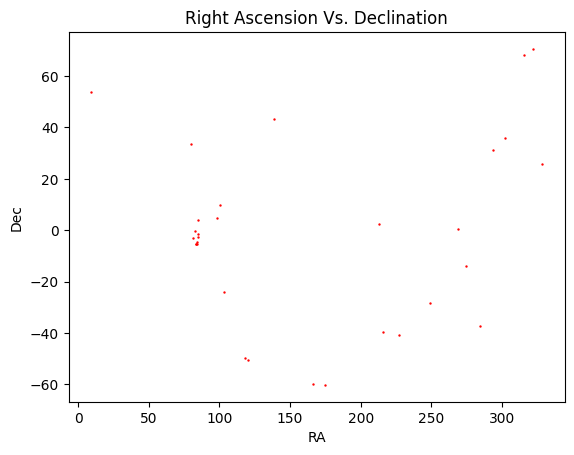

In [5]:
mphot.ra_vs_dec(df)

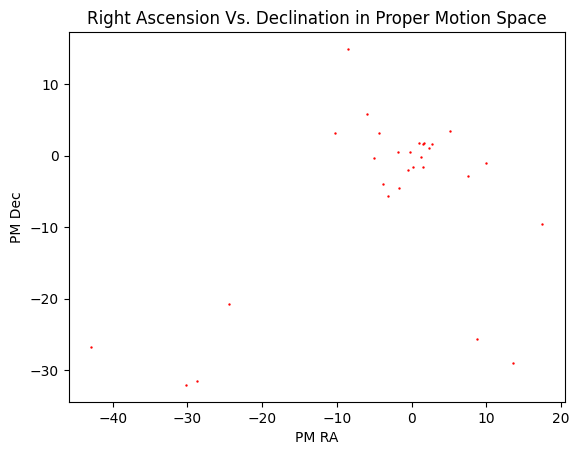

In [6]:
mphot.pmra_vs_pmdec(df)

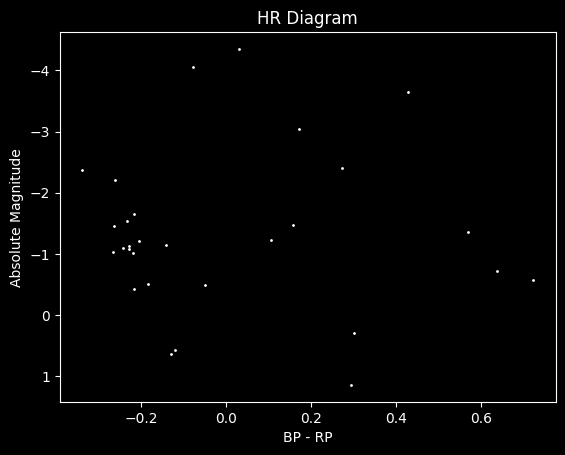

31


In [7]:
mphot.plot_hr_diagram(df)
print(len(df))

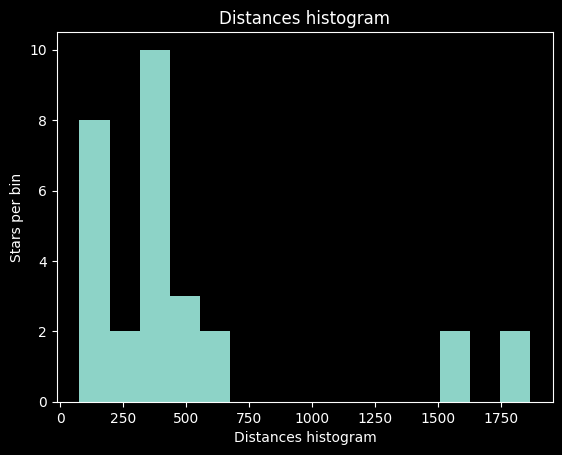

Distances histogram, meidian: 392.72490131328766
Standard Deviation: 502.2500409557288


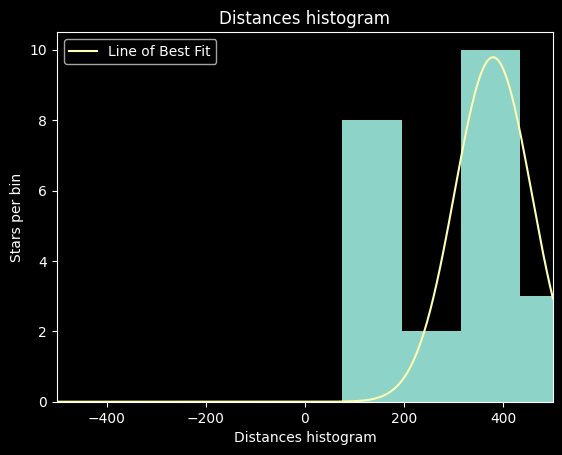

In [8]:
"""
You dont need to copy and paste these, just call mphot.hist or mpoht.fittedHist

def hist(dists, bin_num, parallax=False):
    #Magnitude, Y-Values

    #Adjust if dist given in parallax
    if parallax:
        dists = (1000/parallax)

    plt.title("Distances of Stars in Sample Histogram")
    plt.hist(dists, bins=bin_num)

    plt.xlabel('Distance (pc)')
    plt.ylabel('Stars per bin')
    plt.show()

def gaussian(x, A, sigma, mu):
    return A*(1/(sigma * np.sqrt(2*np.pi)) * np.exp(-1*(x - mu)**2 / (2*sigma**2)))

def fittedHist(dists, bin_num=50, range=[-500,500],parallax=False):
    #Magnitude, Y-Values
    if parallax:
        dists = (1000/parallax)

    median = dists.median()
    std = dists.std()

    print("name"+": "+ str(median))
    plt.title("Starcount Histogram: "+ "name")

    h_1d_output = plt.hist(dists, bins=bin_num)
    x_plot = np.linspace(range[0],range[1], 300)
    x_1d_fit = (h_1d_output[1][:-1]+h_1d_output[1][1:])/2
    y_1d_fit = h_1d_output[0]
    fit = curve_fit(gaussian, x_1d_fit, y_1d_fit, p0 = [55, std, median])
    print("Standard Deviation: "+str(dists.std()))

    #Fix printing this
    #print(fit)
    plt.plot(x_plot, gaussian(x_plot, *fit[0]), label ='Line of Best Fit')

    plt.xlim(range[0], range[1])
    plt.xlabel('Distance (pc)')
    plt.ylabel('Stars per bin')
    plt.legend()
    plt.show()
"""
#dists = (1000/df["parallax"]) 
#dont need to do 1000 over parralax here. It does it automatically in the function if you set parallax to be true

bin_num = 15

mphot.hist(df['parallax'], bin_num, parallax=True)
mphot.fittedHist(df['parallax'], bin_num, range=[-500,500],parallax=True)

In [ ]:
#Now I will be testing the epoch photometry for one of the stars on the list: 4371780385208211584

source_id = 4371780385208211584

df = (gi.query_by_datalink(source_id))[source_id]
print(f"Retrieved {len(df)} rows")
df.head()

PermissionError: [WinError 5] Access is denied: 'c:\\Users\\nakia\\OneDrive\\Documents\\GitHub\\gaiadr3-analysis\\notebooks\\temp_20260617_180345.471145'

In [10]:
#Plot light curve unphased.
ephot.lightcurve(df)

KeyError: 'DataFrame is missing required columns: bp_mag, bp_obs_time, g_transit_mag, g_transit_time, rp_mag, rp_obs_time'

In [ ]:
period = ephot.lomb_scargle(df['g_transit_time'], df['g_transit_mag'], period_range = [0.1, 18], plot = True)

KeyError: 'g_transit_time'

In [11]:
#Plot light curve phased:
ephot.lightcurve(df, period = period)

NameError: name 'period' is not defined